# Exploring Bible Embeddings

This notebook builds intuition for what semantic embeddings are and how they work on the KJV corpus. No prior ML experience assumed.

The core idea: every verse has been converted into a list of 768 numbers (a *vector*) such that verses with similar *meaning* end up with similar vectors — regardless of whether they share the same words.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path

from sacred_semantics.corpus.bible import load_segments
from sacred_semantics.pipeline.embed import load as load_embeddings, load_model, encode

## 1. Load the corpus and embeddings

In [2]:
segments = load_segments(Path('../data/processed/bible_kjv.json'))
embeddings = load_embeddings(Path('../embeddings/bible_kjv_all_mpnet_base_v2.npy'))

print(f'Verses:     {len(segments):,}')
print(f'Embeddings: {embeddings.shape}  (one 768-dim vector per verse)')
print(f'\nFirst verse: {segments[0]["ref"]} — {segments[0]["text"]}')

Verses:     31,102
Embeddings: (31102, 768)  (one 768-dim vector per verse)

First verse: Genesis 1:1 — In the beginning God created the heaven and the earth.


## 2. What does an embedding actually look like?

Each verse is a point in 768-dimensional space. Here are the first 20 numbers from Genesis 1:1 — not human-readable, but the *geometry* between these vectors is what carries meaning.

In [3]:
gen_1_1 = embeddings[0]
print(f'Genesis 1:1 vector (first 20 of 768 values):')
print(np.round(gen_1_1[:20], 4))
print(f'\nVector magnitude: {np.linalg.norm(gen_1_1):.4f}  (normalized to ~1.0)')

Genesis 1:1 vector (first 20 of 768 values):
[ 0.0408  0.0421  0.0027  0.0068  0.005  -0.0098 -0.0409 -0.0575 -0.0463
  0.0341  0.0086 -0.0071  0.0159 -0.0282  0.0615 -0.0358 -0.0147 -0.0138
 -0.0667  0.0355]

Vector magnitude: 1.0000  (normalized to ~1.0)


## 3. Cosine similarity — the core measurement

We measure similarity by the *angle* between two vectors:
- **1.0** = identical meaning
- **0.5–0.8** = related meaning  
- **~0.0** = unrelated

Let's try a famous cross-testament pair: Genesis 1:1 and John 1:1. Both begin "In the beginning" — but more importantly, both are about the pre-existent creative Word/God.

In [4]:
def find_verse(ref: str) -> tuple[int, dict]:
    """Return (index, segment) for a verse reference like 'John 3:16'."""
    for i, s in enumerate(segments):
        if s['ref'] == ref:
            return i, s
    raise ValueError(f'Verse not found: {ref}')

def similarity(ref_a: str, ref_b: str) -> float:
    ia, _ = find_verse(ref_a)
    ib, _ = find_verse(ref_b)
    return cosine_similarity(embeddings[[ia]], embeddings[[ib]])[0, 0]

pairs = [
    ('Genesis 1:1',  'John 1:1'),       # famous parallel — creation / the Word
    ('Psalms 23:1',  'John 10:11'),     # shepherd imagery
    ('John 3:16',    'Romans 5:8'),     # God's love / atonement
    ('Genesis 1:1',  'Revelation of John 22:21'),  # first vs. last verse — unrelated
]

print(f'{"Pair":<45}  Similarity')
print('-' * 58)
for a, b in pairs:
    score = similarity(a, b)
    ia, sa = find_verse(a)
    ib, sb = find_verse(b)
    print(f'{a} / {b:<25}  {score:.4f}')
    print(f'  "{sa["text"][:70]}"')
    print(f'  "{sb["text"][:70]}"')
    print()

Pair                                           Similarity
----------------------------------------------------------
Genesis 1:1 / John 1:1                   0.4904
  "In the beginning God created the heaven and the earth."
  "In the beginning was the Word, and the Word was with God, and the Word"

Psalms 23:1 / John 10:11                 0.6151
  "The Lord is my shepherd; I shall not want."
  "I am the good shepherd: the good shepherd giveth his life for the shee"

John 3:16 / Romans 5:8                 0.6719
  "For God so loved the world, that he gave his only begotten Son, that w"
  "But God commendeth his love toward us, in that, while we were yet sinn"

Genesis 1:1 / Revelation of John 22:21   0.1471
  "In the beginning God created the heaven and the earth."
  "The grace of our Lord Jesus Christ be with you all. Amen.   "



## 4. Finding the most similar verses to a query

This is the core operation we'll run against BCP passages later. Given any text, embed it and find the closest verses in the corpus.

In [5]:
model = load_model('all-mpnet-base-v2')

def top_matches(query: str, k: int = 8) -> None:
    q_vec = encode([query], model)
    scores = cosine_similarity(q_vec, embeddings)[0]
    top_k = np.argsort(scores)[::-1][:k]
    print(f'Query: "{query}"\n')
    for rank, idx in enumerate(top_k, 1):
        s = segments[idx]
        print(f'  {rank}. [{scores[idx]:.4f}] {s["ref"]} ({s["genre"]})')
        print(f'     {s["text"][:100]}')

top_matches('The Lord is my shepherd')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Query: "The Lord is my shepherd"

  1. [0.8071] Psalms 23:1 (Wisdom)
     The Lord is my shepherd; I shall not want.
  2. [0.7657] Ezekiel 34:7 (Major Prophets)
     Therefore, ye shepherds, hear the word of the Lord;
  3. [0.7651] Ezekiel 34:9 (Major Prophets)
     Therefore, O ye shepherds, hear the word of the Lord;
  4. [0.7258] John 10:11 (Gospel)
     I am the good shepherd: the good shepherd giveth his life for the sheep.
  5. [0.6837] John 10:14 (Gospel)
     I am the good shepherd, and know my sheep, and am known of mine.
  6. [0.6595] Psalms 54:4 (Wisdom)
     Behold, God is mine helper: the Lord is with them that uphold my soul.
  7. [0.6576] I Peter 5:4 (General Epistle)
     And when the chief Shepherd shall appear, ye shall receive a crown of glory that fadeth not away.
  8. [0.6538] Ezekiel 34:12 (Major Prophets)
     As a shepherd seeketh out his flock in the day that he is among his sheep that are scattered; so wil


In [6]:
# Try your own query here
top_matches('forgiveness of sins through grace')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Query: "forgiveness of sins through grace"

  1. [0.6951] Romans 4:7 (Pauline Epistle)
     Saying, Blessed are they whose iniquities are forgiven, and whose sins are covered.
  2. [0.6905] Psalms 32:1 (Wisdom)
     Blessed is he whose transgression is forgiven, whose sin is covered.
  3. [0.6840] Acts 13:38 (History)
     Be it known unto you therefore, men and brethren, that through this man is preached unto you the for
  4. [0.6839] Colossians 1:14 (Pauline Epistle)
     In whom we have redemption through his blood, even the forgiveness of sins:
  5. [0.6810] Luke 11:4 (Gospel)
     And forgive us our sins; for we also forgive every one that is indebted to us. And lead us not into 
  6. [0.6677] Matthew 9:6 (Gospel)
     But that ye may know that the Son of man hath power on earth to forgive sins, (then saith he to the 
  7. [0.6579] Ephesians 2:8 (Pauline Epistle)
     For by grace are ye saved through faith; and that not of yourselves: it is the gift of God:
  8. [0.6480] Romans 5

## 5. Genre distribution of the corpus

Quick look at how many verses fall into each genre — useful context for interpreting similarity results later.

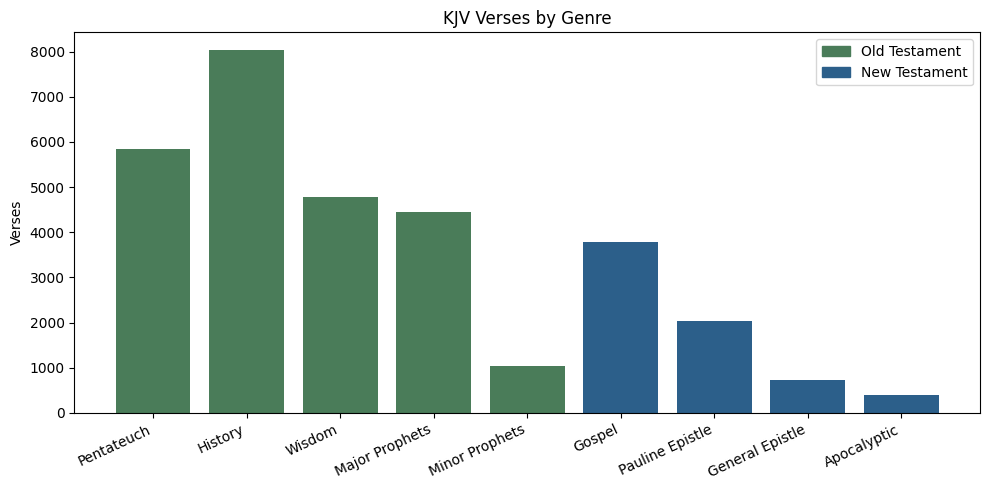

  History                8,025
  Pentateuch             5,852
  Wisdom                 4,785
  Major Prophets         4,440
  Gospel                 3,779
  Pauline Epistle        2,033
  Minor Prophets         1,050
  General Epistle        734
  Apocalyptic            404


In [7]:
from collections import Counter

genre_counts = Counter(s['genre'] for s in segments)
genres = list(genre_counts.keys())
counts = [genre_counts[g] for g in genres]

# Sort by OT then NT, descending count within each
ot_genres = [g for g in genres if any(s['testament'] == 'OT' and s['genre'] == g for s in segments)]
nt_genres = [g for g in genres if g not in ot_genres]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4a7c59' if g in ot_genres else '#2c5f8a' for g in genres]
bars = ax.bar(genres, counts, color=colors)
ax.set_ylabel('Verses')
ax.set_title('KJV Verses by Genre')
plt.xticks(rotation=25, ha='right')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4a7c59', label='Old Testament'),
                   Patch(color='#2c5f8a', label='New Testament')])
plt.tight_layout()
plt.show()

for g, c in sorted(genre_counts.items(), key=lambda x: -x[1]):
    print(f'  {g:<22} {c:,}')

## 6. Where this is heading

Once BCP 2019 passages are embedded, the workflow becomes:

1. For each BCP segment, run `top_matches()` against all 31k verses
2. Record each segment's **maximum similarity score** and the verse it matched
3. Sweep a similarity threshold (0.5 → 0.95) and count what fraction of BCP is above it
4. That curve answers the core research question: *what does "derived from Scripture" actually mean computationally?*